In [ ]:
# Path shim: this notebook lives in supplementary/, but imports and data/
# checkpoint paths throughout the pipeline are relative to the repo root.
import os, sys
_PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, _PROJECT_ROOT)


In [1]:
import utils_inverse
import utils_plotting
%load_ext autoreload
%autoreload 2

# Use inverse model to find optimal emissions time series for all forcing agents
Differs from previous optimization as some scenarios are omitted (abrupt quadrupling experiments)

## 1. Generate initial parameters, test backpropagation, and create baseline emulator

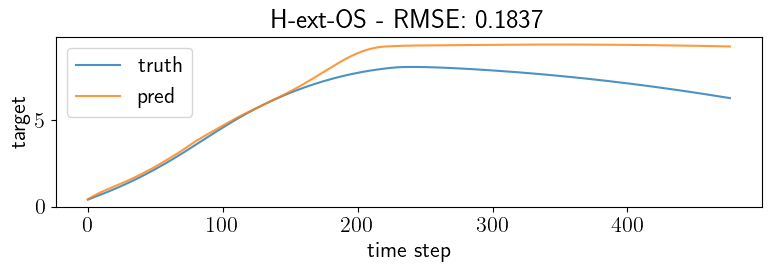

Getting gradient for historical...
	||grad BC||: 0.0025398300494998693
	||grad CH4||: 3.985055809607729e-05
	||grad CO2||: 0.0002717208117246628
	||grad N2O||: 0.001030437182635069
	||grad Sulfur||: 6.44300744170323e-05


In [2]:
# Required to generate baseline parameters
agents        = ['CO2','CH4',
                 'N2O','Sulfur',
                 'BC']          # Forcing agents included in temperatutre simulations
active_agents = ('CO2','CH4',
                 'N2O','Sulfur',
                 'BC')          # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]            # Dimension of neural network emulator
idx_demo      = 1               # Index of scenario to plot
test_scen     = 'historical'    # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False           # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

In [3]:
# Generate data for emulator evaluation
(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True)

In [4]:
# Baseline emulator parameters
save_path   = 'checkpoints/multi/baseline_all_agents_subset.pkl' # Location to save baseline data
verbose     = False # Flag to print NRMSE values from the baseline emulator

# Create baseline emulator
baseline_results, baseline_pred_delT, ground_truth_delT = utils_inverse.generate_and_eval_baseline_emulator(emis_dict_tier1_JAX,
                                                                                                            eval_sets, save_path=save_path,
                                                                                                            verbose=verbose, hidden_sizes=hidden_sizes)

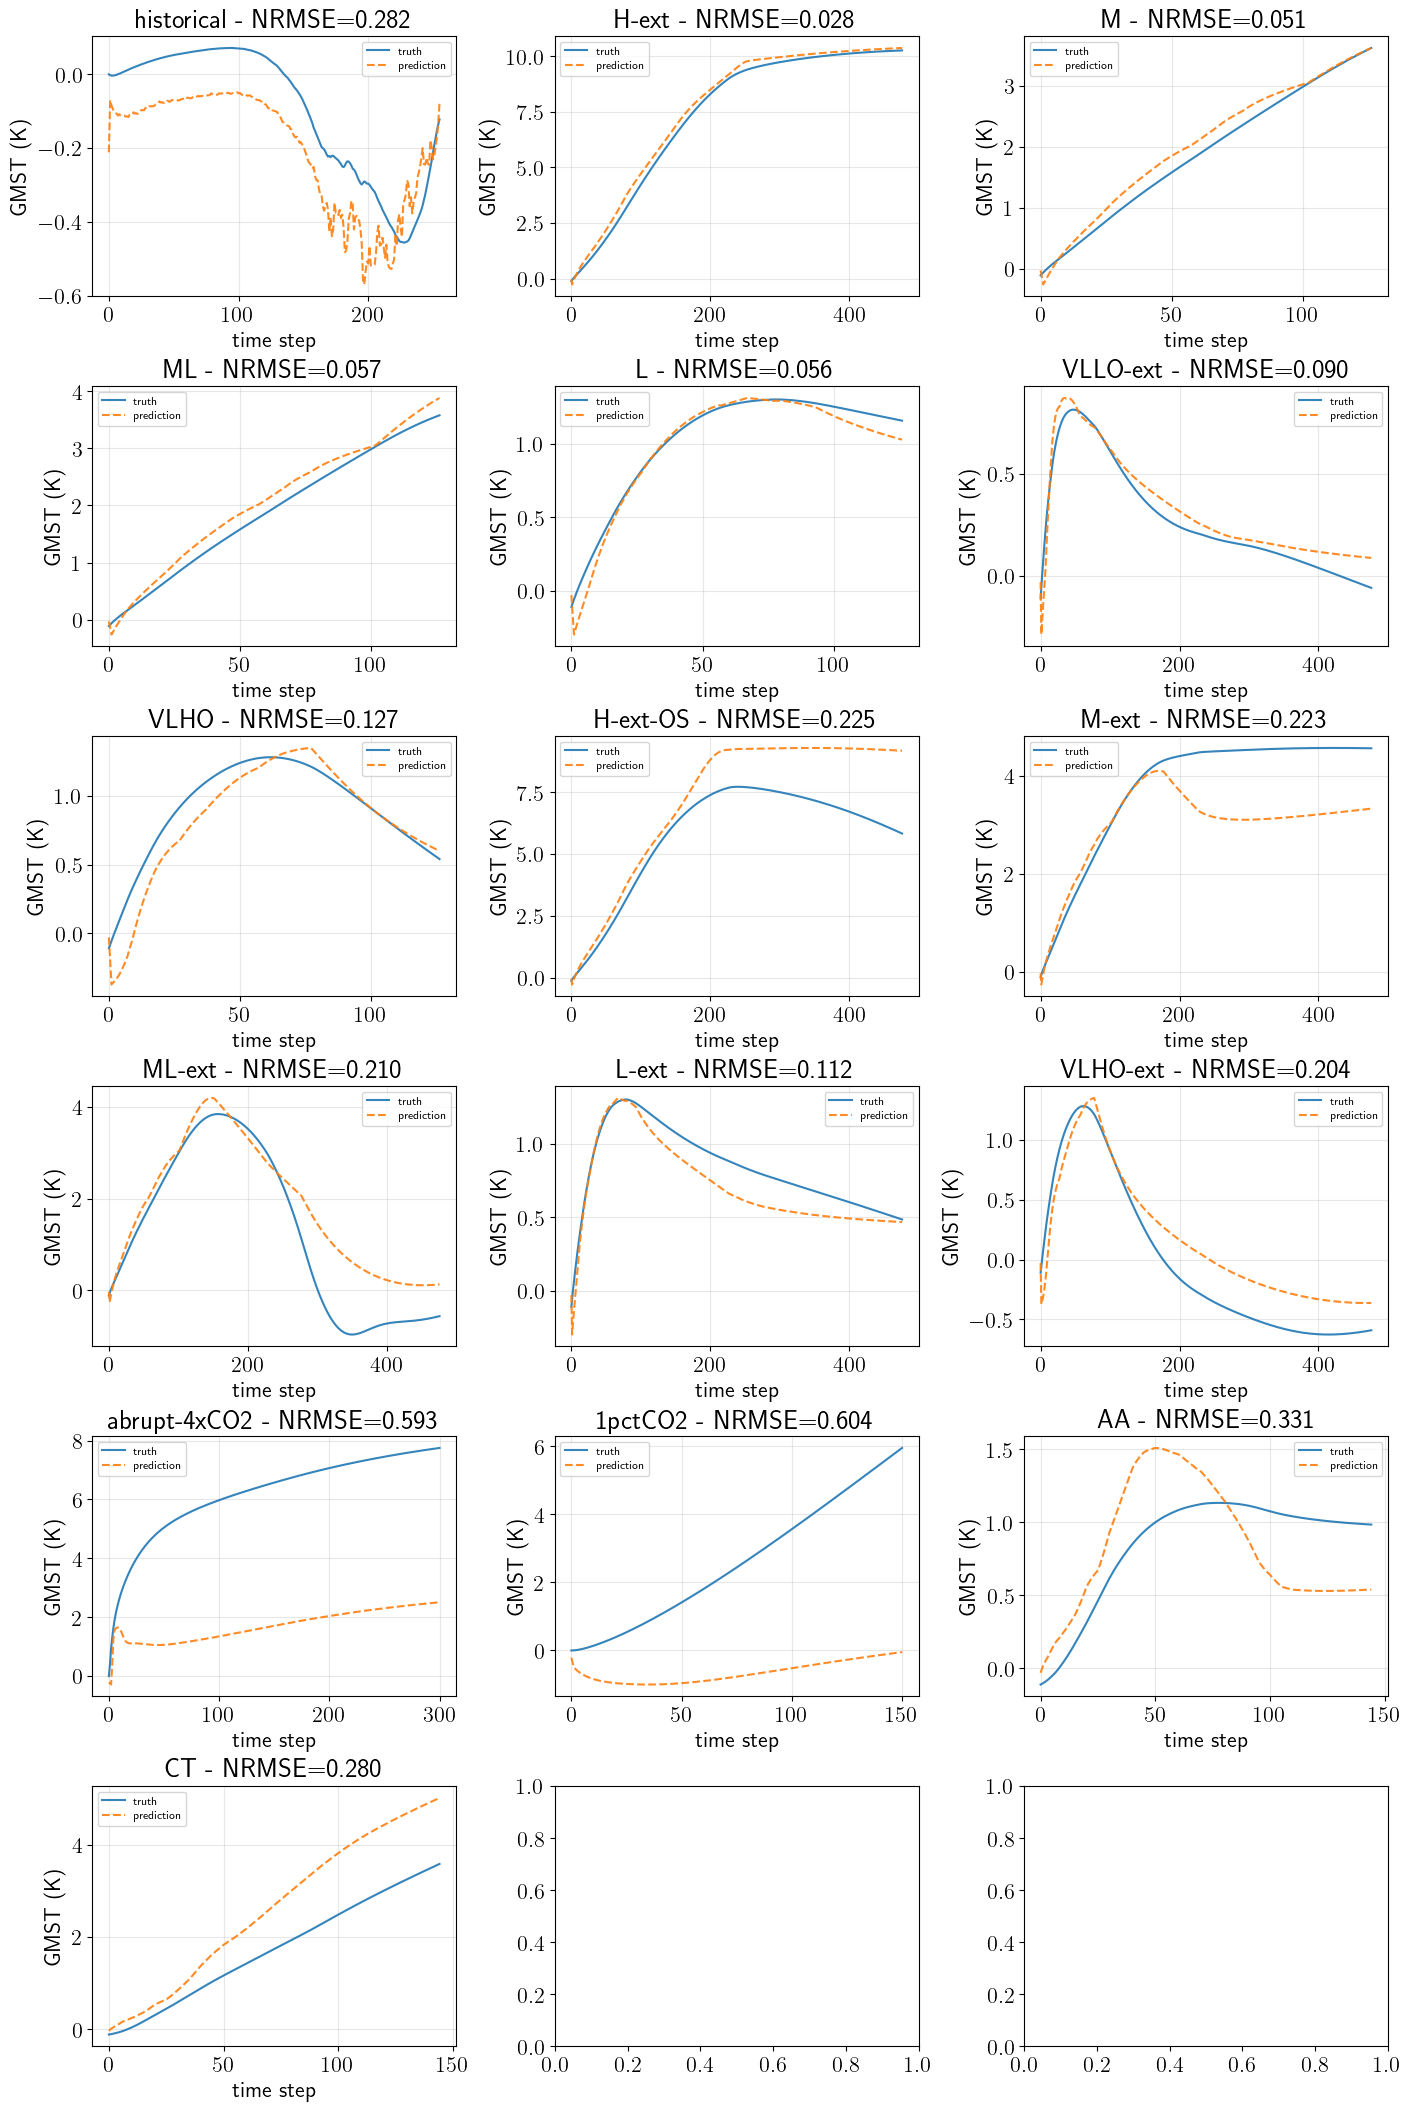

In [5]:
# Optional: plot predictions of baseline emulator
utils_plotting.plot_baseline_pred_delT(baseline_results, baseline_pred_delT, ground_truth_delT)

## 2. Optimize all emissions time series used in training

### 2a. Optimize training data for predictive skill over all evaluation sets
For this experiment, the stability of the results are sensitive to the step size taken for each forcing agent, along with the weight of the smoothness penalty. The step sizes and smoothness weights used for each set of scenarios can be found in cell directly below.

In [ ]:
# Params - tier 1: {'CO2':1e1, 'CH4':5e2, 'N2O':1e1, 'Sulfur':1e1, 'BC':5e0}, 1e-5, 4k
#          tier 2: {'CO2':5e1, 'CH4':1e3, 'N2O':5e1, 'Sulfur':5e1, 'BC':1e1}, 1e-5, 6k
#          DECK:   {'CO2':5e1, 'CH4':1e3, 'N2O':5e1, 'Sulfur':5e1, 'BC':1e1}, 1e-5, 1.4k
#          CS3:    {'CO2':1e1, 'CH4':1e3, 'N2O':5e1, 'Sulfur':5e1, 'BC':1e1}, 1e-5, 5k
#          all:    {'CO2':5e1, 'CH4':1e3, 'N2O':5e1, 'Sulfur':5e1, 'BC':1e1}, 1e-4, 5k

In [ ]:
# Compute migrated to scripts/supplementary/SIe_inverse_all_agents_subset.py (run standalone / scheduled) - this cell just loads the resulting checkpoints.
results_dict = {
    'tier1': utils_inverse.load_inverse_ckpt('checkpoints/multi/inverse_sine_tier1_all_agents_subset2.pkl')
}


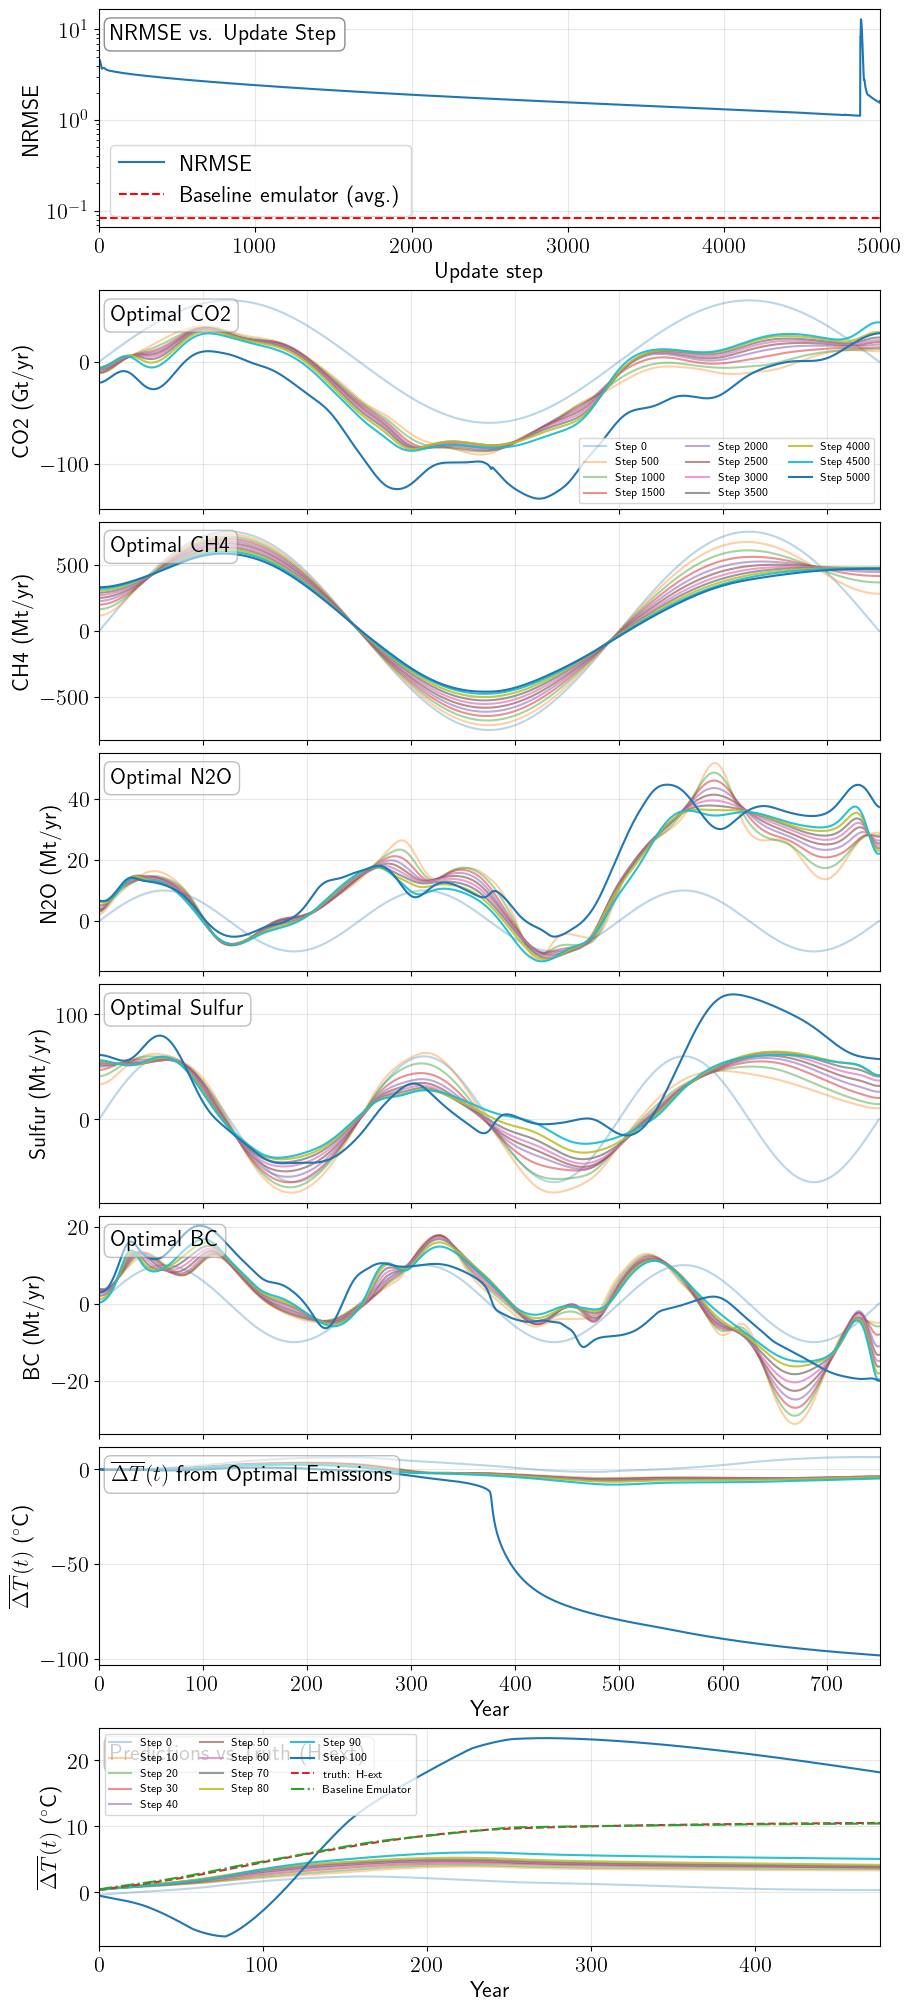

In [25]:
# Optional: plot results of optimization
## Plotting parameters
opt_test        = 'tier1'  # Evaluation set to plot optimized results for
baseline_test   = 'Tier 1' # Evaluation set to plot results for
predict_plot    = 'H-ext'  # Individual scenario to plot predictions

utils_plotting.plot_inverse_results(
    results_dict[opt_test],
    baseline_results[baseline_test]['mean'],
    active_agents=active_agents,
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT[baseline_test][predict_plot]
)